### IMPORTS

In [1]:
import os
import numpy
import matplotlib.pyplot as plot
import tensorflow
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
import seaborn
import pandas
import json

### LOAD MODEL & CLASS NAMES

In [2]:
model_path = "../saved/resnet_model.h5"
class_names_path = "../saved/class_names.json"

resnet_model = tensorflow.keras.models.load_model(model_path)

with open(class_names_path, "r") as f:
    class_names = json.load(f)

### SET DATA PATHS & LAST CONV LAYER

In [3]:
sample_dir = "../data/brain_tumor/testing"
class_folders = sorted(os.listdir(sample_dir))

last_conv_name = "conv5_block3_out"

### LOAD IMAGES

In [4]:
def load_and_preprocess_image(img_path):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_pre = preprocess_input(img_array)
    img_batch = numpy.expand_dims(img_pre, axis=0)
    return img, img_batch

### DISPLAYING GRAD-CAM HELPER FUNCTIONS

In [5]:
def display_gradcam(img, heatmap, alpha=0.4, cmap_name="jet"):

    heatmap_resized = tensorflow.image.resize(heatmap[..., numpy.newaxis], (img.size[1], img.size[0]), method="bilinear").numpy().squeeze()

    cmap = plot.get_cmap(cmap_name)
    heatmap_colored = cmap(heatmap_resized)
    heatmap_colored = heatmap_colored[..., :3]  # drop alpha channel

    overlay = heatmap_colored * alpha + (numpy.array(img) / 255.0) * (1 - alpha)

    plot.figure(figsize=(8,4))
    plot.subplot(1,2,1); plot.imshow(img); plot.axis("off"); plot.title("Original")
    plot.subplot(1,2,2); plot.imshow(overlay); plot.axis("off"); plot.title("Overlay")
    plot.show()

### DEFINE GRAD-CAM HEATMAP FUNCTION

In [6]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    base_model = model.get_layer("resnet50")

    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    conv_model = tensorflow.keras.Model(inputs=base_model.input, outputs=last_conv_layer.output)

    classifier_input = tensorflow.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    for layer in model.layers[2:]:  
        x = layer(x)
    classifier_model = tensorflow.keras.Model(classifier_input, x)

    with tensorflow.GradientTape() as tape:
        conv_outputs = conv_model(img_array, training=False)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs, training=False)
        if pred_index is None:
            pred_index = tensorflow.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tensorflow.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tensorflow.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tensorflow.maximum(heatmap, 0)
    heatmap /= tensorflow.reduce_max(heatmap) + 1e-10
    return heatmap.numpy()

### DISPLAY SAMPLE GRAD-CAM IMAGES


Image: Te-glTr_0000.jpg
True: glioma | Pred: glioma


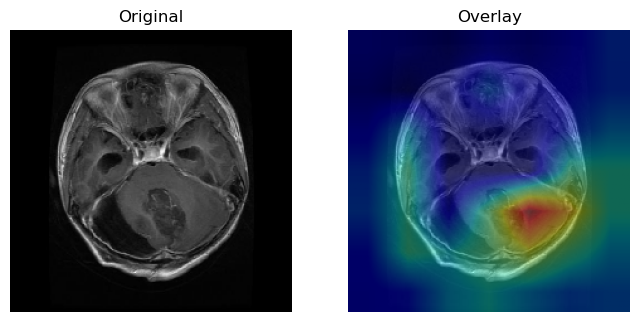


Image: Te-meTr_0000.jpg
True: meningioma | Pred: meningioma


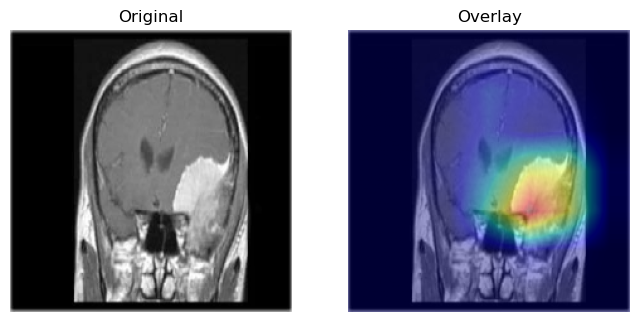


Image: Te-noTr_0000.jpg
True: notumor | Pred: notumor


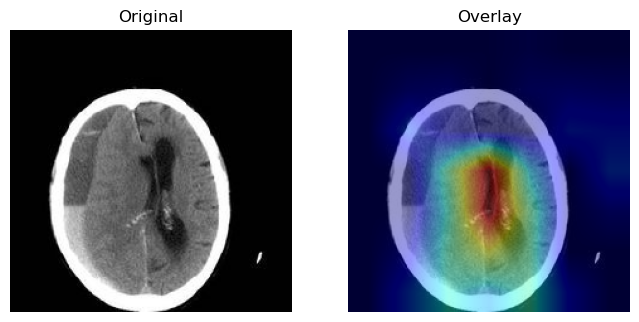


Image: Te-piTr_0000.jpg
True: pituitary | Pred: pituitary


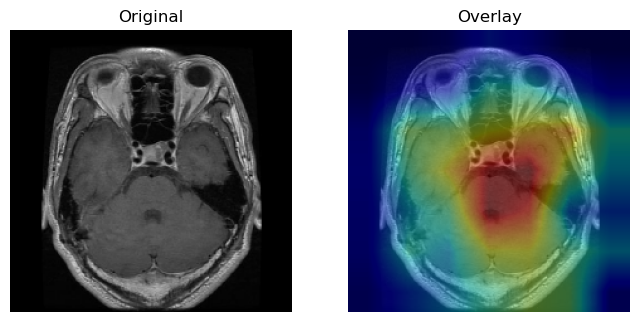

In [7]:
for cls in class_folders:
    class_path = os.path.join(sample_dir, cls)

    img_name = next(
        (f for f in sorted(os.listdir(class_path))
         if f.lower().endswith(('.png', '.jpg', '.jpeg'))),
        None)

    if img_name is None:
        continue

    img_path = os.path.join(class_path, img_name)
    img, img_batch = load_and_preprocess_image(img_path)

    preds = resnet_model.predict(img_batch, verbose=0)
    pred_class_idx = numpy.argmax(preds[0])
    pred_label = class_names[pred_class_idx]

    heatmap = make_gradcam_heatmap(img_batch, resnet_model, last_conv_name, pred_class_idx)

    print(f'\nImage: {img_name}')
    print(f'True: {cls} | Pred: {pred_label}')

    display_gradcam(img, heatmap)

### COLLECT PREDICTION METRICS

In [8]:
activation_records = []
coverage_records = []
misclassified_counts = {cls: 0 for cls in class_folders}

for cls in class_folders:
    class_path = os.path.join(sample_dir, cls)

    for img_name in os.listdir(class_path):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img_path = os.path.join(class_path, img_name)
        img, img_batch = load_and_preprocess_image(img_path)

        preds = resnet_model.predict(img_batch, verbose=0)
        pred_class_idx = numpy.argmax(preds[0])
        pred_label = class_names[pred_class_idx]

        heatmap = make_gradcam_heatmap(img_batch, resnet_model, last_conv_name, pred_class_idx)
        heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-10)
        activation_strength = float(numpy.mean(heatmap_norm))
        coverage_ratio = float(numpy.mean(heatmap_norm > 0.5))

        activation_records.append([cls, activation_strength])
        coverage_records.append([cls, activation_strength, coverage_ratio])

        if pred_label != cls:
            misclassified_counts[cls] += 1

### VIOLIN PLOT

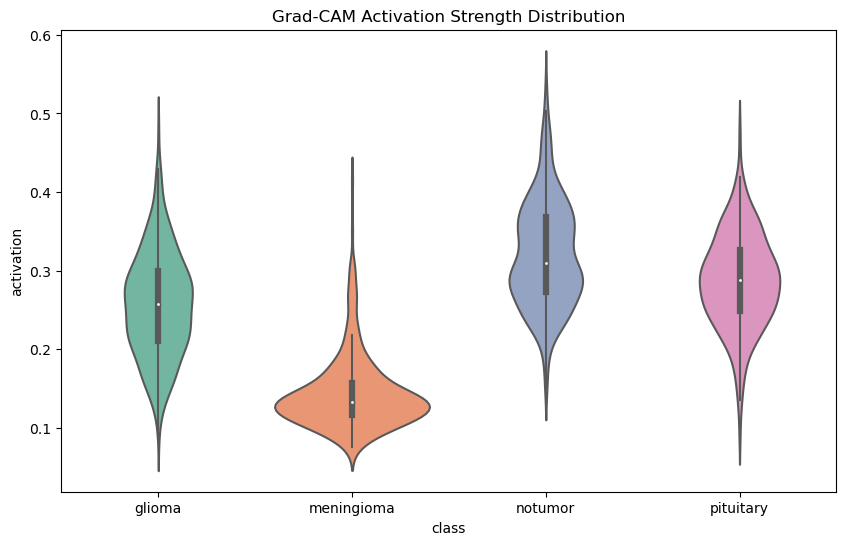

In [9]:
df_violin = pandas.DataFrame(activation_records, columns=["class", "activation"])
plot.figure(figsize=(10,6))
seaborn.violinplot(data=df_violin, x="class", y="activation", palette="Set2")
plot.title("Grad-CAM Activation Strength Distribution")
plot.show()